# Week 4 Assignment - Image Classification on CIFAR-10 (ANN vs CNN)

Name: Deeptesh Mohapatra

Dataset: CIFAR-10 (built into Keras) - 60,000 color images of size 32x32, in 10 classes
(airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).

Goal: build image classification models on CIFAR-10 and compare how they do across different
architectures and training strategies. I build both a plain neural network (ANN) and
convolutional networks (CNN), and then look at what helps.

Plan:

1. Load CIFAR-10 and look at the images
2. Preprocess (scale the pixels)
3. Model 1: a plain ANN (fully connected) as a baseline
4. Model 2: a basic CNN
5. Model 3: an improved CNN with batch normalization, dropout and data augmentation
6. Compare all three (accuracy, training curves, confusion matrix, sample predictions)
7. Write up what worked and why

## Setup

Importing the libraries and fixing the random seed so results are repeatable.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'      # hide tensorflow info logs
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.21.0


GPU available: False


## 1. Loading the data and looking at it

CIFAR-10 comes as 6 batch files (5 training, 1 test) in the standard Python pickle format. I
pull them from Kaggle with kagglehub (this is fast and cached) and read them into numpy arrays.
Each image is stored as a flat vector of 3072 values (1024 red, then green, then blue), so I
reshape it back to 32x32x3.

In [2]:
import kagglehub, pickle, glob

def load_cifar10():
    root = kagglehub.dataset_download('pankrzysiu/cifar10-python')
    base = glob.glob(os.path.join(root, '**', 'cifar-10-batches-py'), recursive=True)[0]
    def unpickle(f):
        with open(f, 'rb') as fo:
            return pickle.load(fo, encoding='bytes')
    xs, ys = [], []
    for i in range(1, 6):
        d = unpickle(os.path.join(base, 'data_batch_%d' % i))
        xs.append(d[b'data']); ys += d[b'labels']
    x_train = np.concatenate(xs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train = np.array(ys)
    dt = unpickle(os.path.join(base, 'test_batch'))
    x_test = dt[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_test = np.array(dt[b'labels'])
    return (x_train, y_train), (x_test, y_test)

(x_train, y_train), (x_test, y_test) = load_cifar10()
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print('Train images:', x_train.shape, '| Train labels:', y_train.shape)
print('Test images :', x_test.shape, '| Test labels :', y_test.shape)
print('Pixel value range:', x_train.min(), 'to', x_train.max())
print('Number of classes:', len(class_names))

C:\Users\lenovo\Desktop\Celebal_Internship\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train images: (50000, 32, 32, 3) | Train labels: (50000,)
Test images : (10000, 32, 32, 3) | Test labels : (10000,)
Pixel value range: 0 to 255
Number of classes: 10


### 1.1 A few sample images

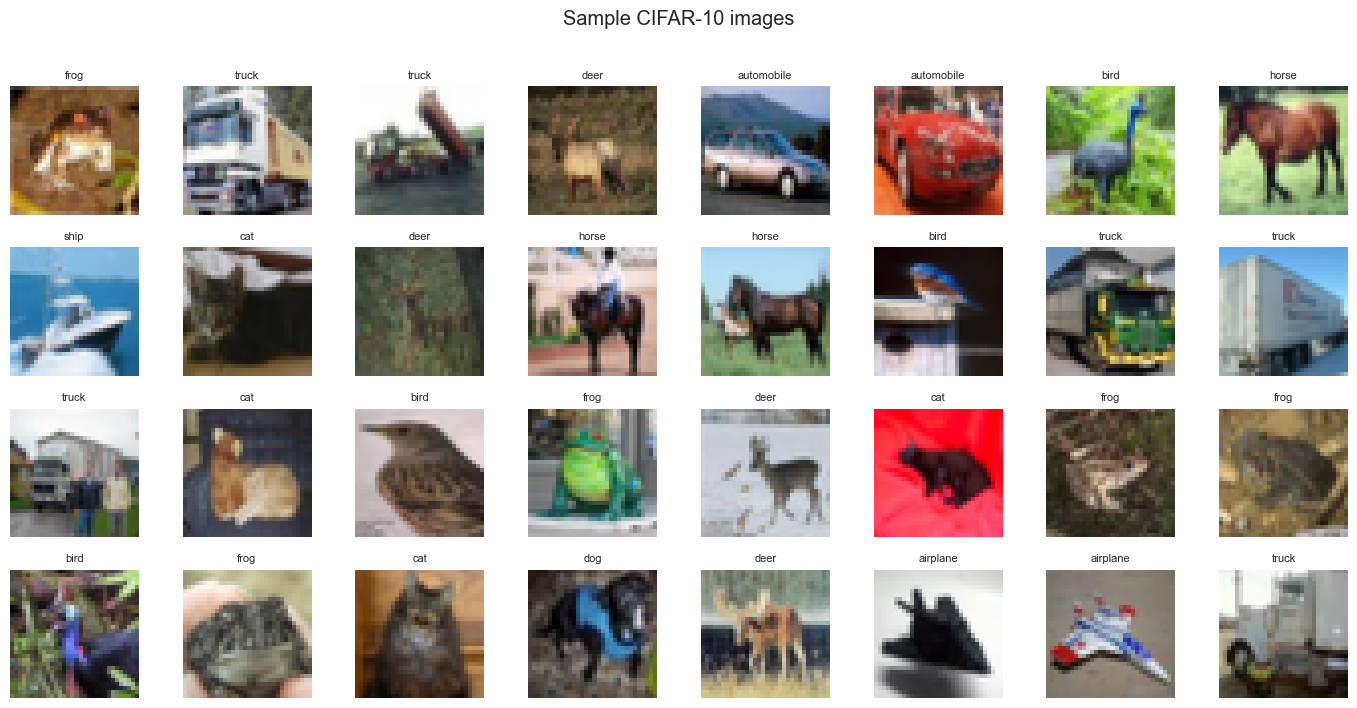

In [3]:
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(y_train[i])], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 images', y=1.01)
plt.tight_layout(); plt.show()

### 1.2 Are the classes balanced?

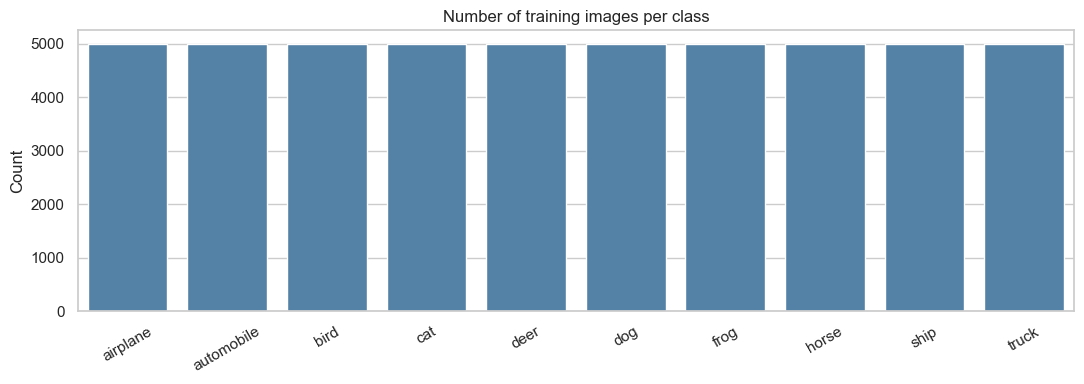

Images per class: {'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [4]:
unique, counts = np.unique(y_train, return_counts=True)
fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(x=[class_names[u] for u in unique], y=counts, ax=ax, color='steelblue')
ax.set_title('Number of training images per class')
ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print('Images per class:', dict(zip([class_names[u] for u in unique], counts)))

The dataset is perfectly balanced - 5000 training images for each of the 10 classes.

## 2. Preprocessing

Two simple steps:

- Scale the pixel values from 0-255 down to 0-1, which helps the network train.
- Keep the labels as integers (0-9). I use the sparse categorical crossentropy loss so I do not
  need to one-hot encode them.

I also carve out a small validation set from the training data so I can watch for overfitting
while training.

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
y_train = y_train.flatten()
y_test  = y_test.flatten()

# hold out 10% of the training data for validation
val_size = 5000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr,  y_tr  = x_train[:-val_size], y_train[:-val_size]
print('Train:', x_tr.shape[0], '| Validation:', x_val.shape[0], '| Test:', x_test.shape[0])

# how many epochs to train each model (kept modest because this runs on CPU)
EPOCHS_ANN  = 15
EPOCHS_CNN  = 10
EPOCHS_CNN2 = 12
BATCH = 128

Train: 45000 | Validation: 5000 | Test: 10000


### A small helper to plot training curves
I will reuse this to show accuracy and loss for the training and validation sets.

In [6]:
def plot_history(history, title):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(h['accuracy'], label='train')
    axes[0].plot(h['val_accuracy'], label='validation')
    axes[0].set_title(title + ' - accuracy'); axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('accuracy'); axes[0].legend()
    axes[1].plot(h['loss'], label='train')
    axes[1].plot(h['val_loss'], label='validation')
    axes[1].set_title(title + ' - loss'); axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('loss'); axes[1].legend()
    plt.tight_layout(); plt.show()

results = {}   # model name -> test accuracy

## 3. Model 1 - a plain ANN (baseline)

First a fully connected network. It flattens each 32x32x3 image into a vector of 3072 numbers
and feeds it through a few dense layers. This throws away the 2D structure of the image, so I
expect it to be the weakest model - it is my baseline.

In [7]:
ann = keras.Sequential([
    layers.Input((32, 32, 3)),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax'),
], name='ANN')
ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.summary()

Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15


352/352 - 28s - 80ms/step - accuracy: 0.2607 - loss: 2.0142 - val_accuracy: 0.3394 - val_loss: 1.8357


Epoch 2/15


352/352 - 24s - 69ms/step - accuracy: 0.3248 - loss: 1.8571 - val_accuracy: 0.3502 - val_loss: 1.7962


Epoch 3/15


...

352/352 - 24s - 69ms/step - accuracy: 0.4151 - loss: 1.6209 - val_accuracy: 0.4488 - val_loss: 1.5650


Epoch 14/15


352/352 - 26s - 74ms/step - accuracy: 0.4166 - loss: 1.6119 - val_accuracy: 0.4468 - val_loss: 1.5695


Epoch 15/15


352/352 - 25s - 72ms/step - accuracy: 0.4161 - loss: 1.6094 - val_accuracy: 0.4386 - val_loss: 1.5718


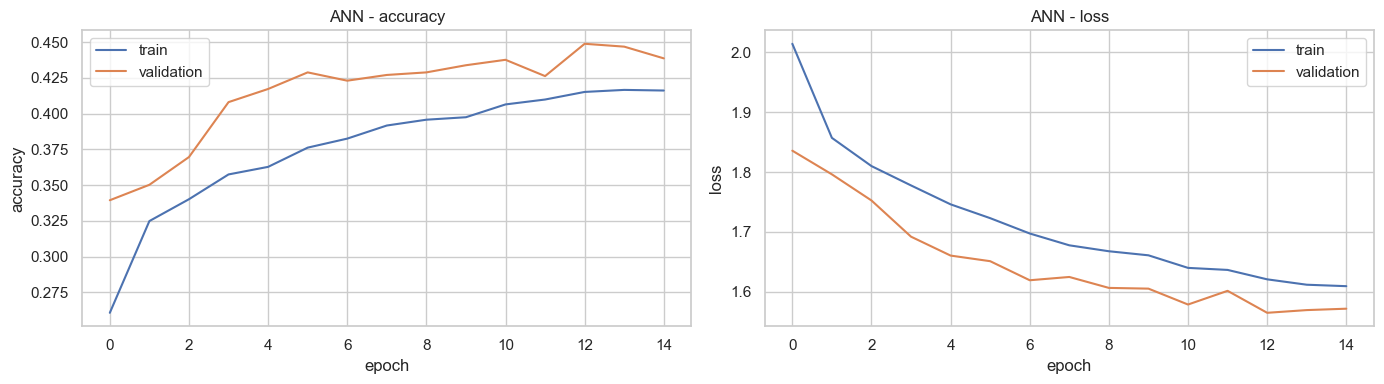

In [8]:
hist_ann = ann.fit(x_tr, y_tr, validation_data=(x_val, y_val),
                   epochs=EPOCHS_ANN, batch_size=BATCH, verbose=2)
plot_history(hist_ann, 'ANN')

In [9]:
ann_loss, ann_acc = ann.evaluate(x_test, y_test, verbose=0)
results['ANN'] = ann_acc
print('ANN test accuracy:', round(ann_acc, 4))

ANN test accuracy: 0.4449


## 4. Model 2 - a basic CNN

A convolutional network keeps the 2D structure and learns small filters that detect edges,
colors and textures. This is the natural tool for images, so it should clearly beat the ANN.
This version is a simple stack of convolution and pooling layers.

In [10]:
cnn = keras.Sequential([
    layers.Input((32, 32, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
], name='Basic_CNN')
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 582,026 (2.22 MB)

 Trainable params: 582,026 (2.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


352/352 - 53s - 151ms/step - accuracy: 0.4321 - loss: 1.5681 - val_accuracy: 0.5482 - val_loss: 1.2548


Epoch 2/10


352/352 - 53s - 150ms/step - accuracy: 0.5874 - loss: 1.1654 - val_accuracy: 0.6260 - val_loss: 1.0461


Epoch 3/10


...

352/352 - 47s - 133ms/step - accuracy: 0.8023 - loss: 0.5711 - val_accuracy: 0.7258 - val_loss: 0.8744


Epoch 9/10


352/352 - 45s - 127ms/step - accuracy: 0.8208 - loss: 0.5213 - val_accuracy: 0.7268 - val_loss: 0.8760


Epoch 10/10


352/352 - 45s - 129ms/step - accuracy: 0.8379 - loss: 0.4709 - val_accuracy: 0.7262 - val_loss: 0.8917


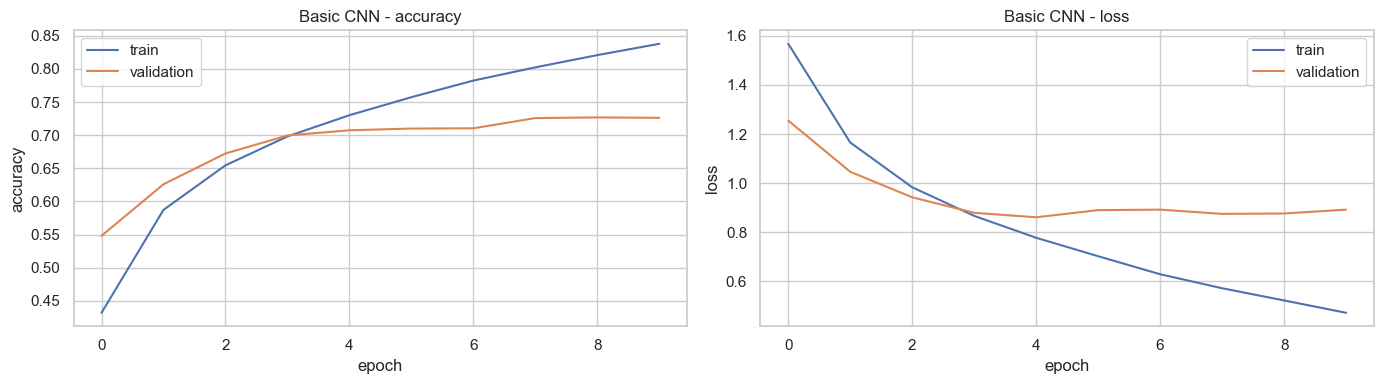

In [11]:
hist_cnn = cnn.fit(x_tr, y_tr, validation_data=(x_val, y_val),
                   epochs=EPOCHS_CNN, batch_size=BATCH, verbose=2)
plot_history(hist_cnn, 'Basic CNN')

In [12]:
cnn_loss, cnn_acc = cnn.evaluate(x_test, y_test, verbose=0)
results['Basic CNN'] = cnn_acc
print('Basic CNN test accuracy:', round(cnn_acc, 4))

Basic CNN test accuracy: 0.7115


## 5. Model 3 - an improved CNN with better training strategies

Now I add the training strategies that usually help image models:

- Batch normalization to stabilize and speed up training
- Dropout to reduce overfitting
- Data augmentation (random horizontal flips) so the model sees more variety of each image
- A deeper stack of convolution blocks with more filters

The augmentation layer is part of the model but only active during training.

In [13]:
data_augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
], name='augment')

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)
    return x

inp = layers.Input((32, 32, 3))
x = data_augment(inp)
x = conv_block(x, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(10, activation='softmax')(x)

cnn2 = keras.Model(inp, out, name='Improved_CNN')
cnn2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn2.summary()

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/12


352/352 - 93s - 265ms/step - accuracy: 0.4180 - loss: 1.7036 - val_accuracy: 0.1438 - val_loss: 3.3107


Epoch 2/12


352/352 - 90s - 257ms/step - accuracy: 0.5484 - loss: 1.2669 - val_accuracy: 0.5838 - val_loss: 1.1904


Epoch 3/12


...

352/352 - 90s - 255ms/step - accuracy: 0.7290 - loss: 0.7787 - val_accuracy: 0.7648 - val_loss: 0.6757


Epoch 11/12


352/352 - 90s - 257ms/step - accuracy: 0.7378 - loss: 0.7562 - val_accuracy: 0.7642 - val_loss: 0.6826


Epoch 12/12


352/352 - 89s - 254ms/step - accuracy: 0.7444 - loss: 0.7350 - val_accuracy: 0.7452 - val_loss: 0.7430


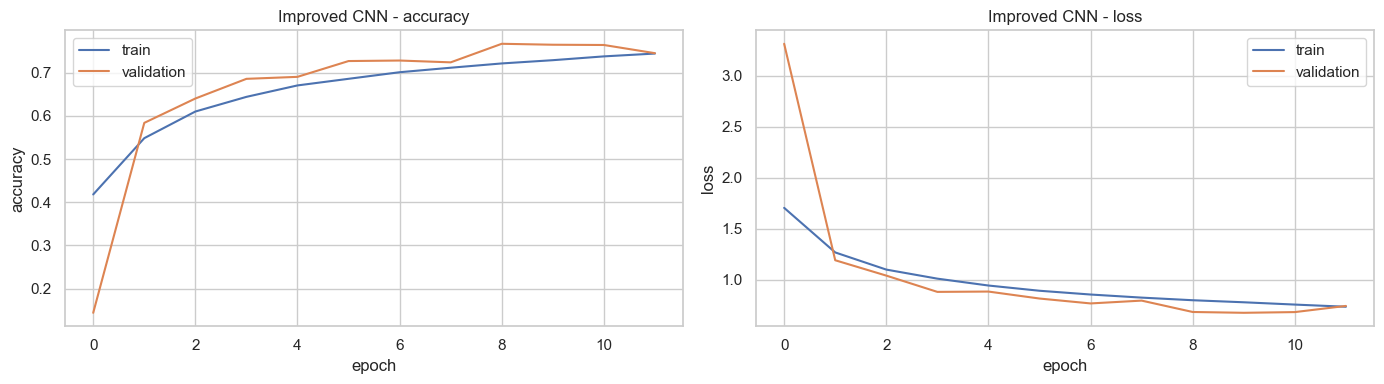

In [14]:
hist_cnn2 = cnn2.fit(x_tr, y_tr, validation_data=(x_val, y_val),
                     epochs=EPOCHS_CNN2, batch_size=BATCH, verbose=2)
plot_history(hist_cnn2, 'Improved CNN')

In [15]:
cnn2_loss, cnn2_acc = cnn2.evaluate(x_test, y_test, verbose=0)
results['Improved CNN'] = cnn2_acc
print('Improved CNN test accuracy:', round(cnn2_acc, 4))

Improved CNN test accuracy: 0.7314


## 6. Comparing the models

In [16]:
import pandas as pd
summary = (pd.DataFrame({'Model': list(results.keys()),
                         'Test accuracy': list(results.values())})
             .sort_values('Test accuracy', ascending=False)
             .reset_index(drop=True))
summary['Test accuracy'] = summary['Test accuracy'].round(4)
summary

,Model,Test accuracy
0,Improved CNN,0.7314
1,Basic CNN,0.7115
2,ANN,0.4449


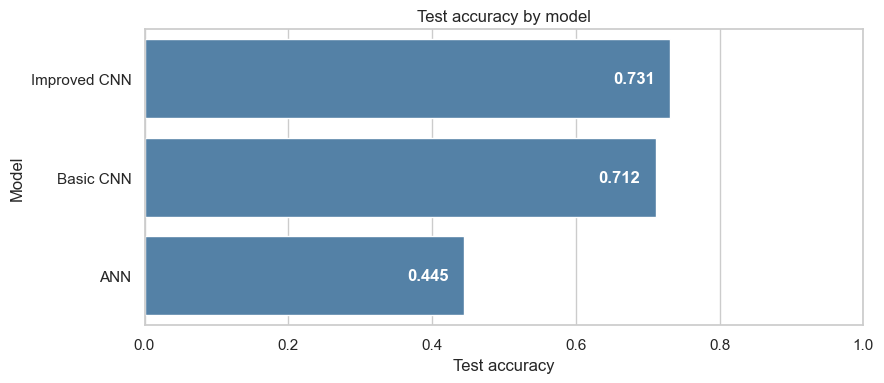

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=summary, x='Test accuracy', y='Model', color='steelblue', ax=ax)
for i, v in enumerate(summary['Test accuracy']):
    ax.text(v - 0.08, i, str(round(v, 3)), color='white', va='center', fontweight='bold')
ax.set_xlim(0, 1); ax.set_title('Test accuracy by model')
plt.tight_layout(); plt.show()

### 6.1 Confusion matrix for the best model

Best model: Improved CNN


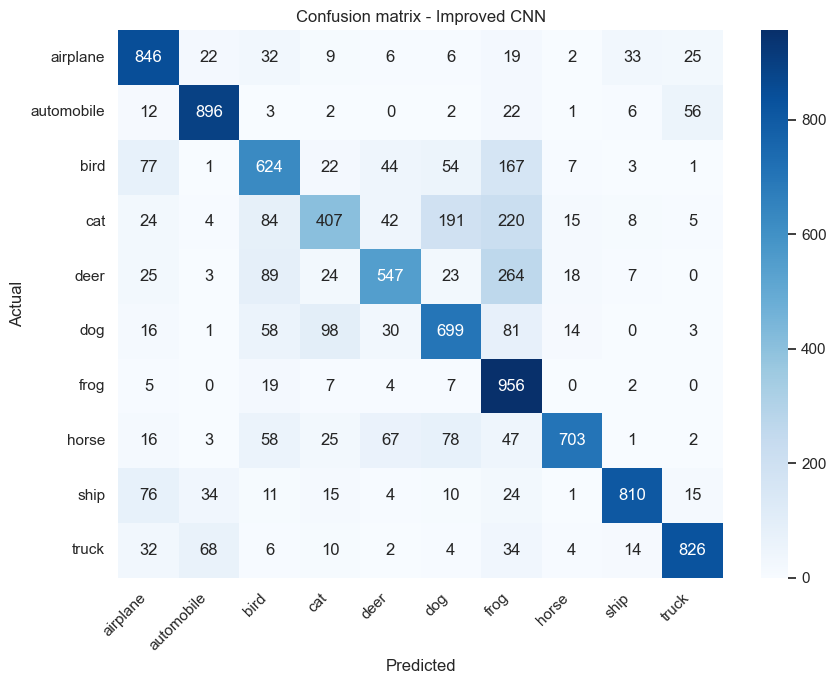

              precision    recall  f1-score   support

    airplane       0.75      0.85      0.79      1000
  automobile       0.87      0.90      0.88      1000
        bird       0.63      0.62      0.63      1000
         cat       0.66      0.41      0.50      1000
        deer       0.73      0.55      0.63      1000
         dog       0.65      0.70      0.67      1000
        frog       0.52      0.96      0.67      1000
       horse       0.92      0.70      0.80      1000
        ship       0.92      0.81      0.86      1000
       truck       0.89      0.83      0.85      1000

    accuracy                           0.73     10000
   macro avg       0.75      0.73      0.73     10000
weighted avg       0.75      0.73      0.73     10000



In [18]:
best_name = summary.iloc[0]['Model']
best_model = {'ANN': ann, 'Basic CNN': cnn, 'Improved CNN': cnn2}[best_name]
print('Best model:', best_name)

y_pred = best_model.predict(x_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion matrix - ' + best_name)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

### 6.2 Some predictions from the best model

Green title means the prediction was correct, red means it was wrong.

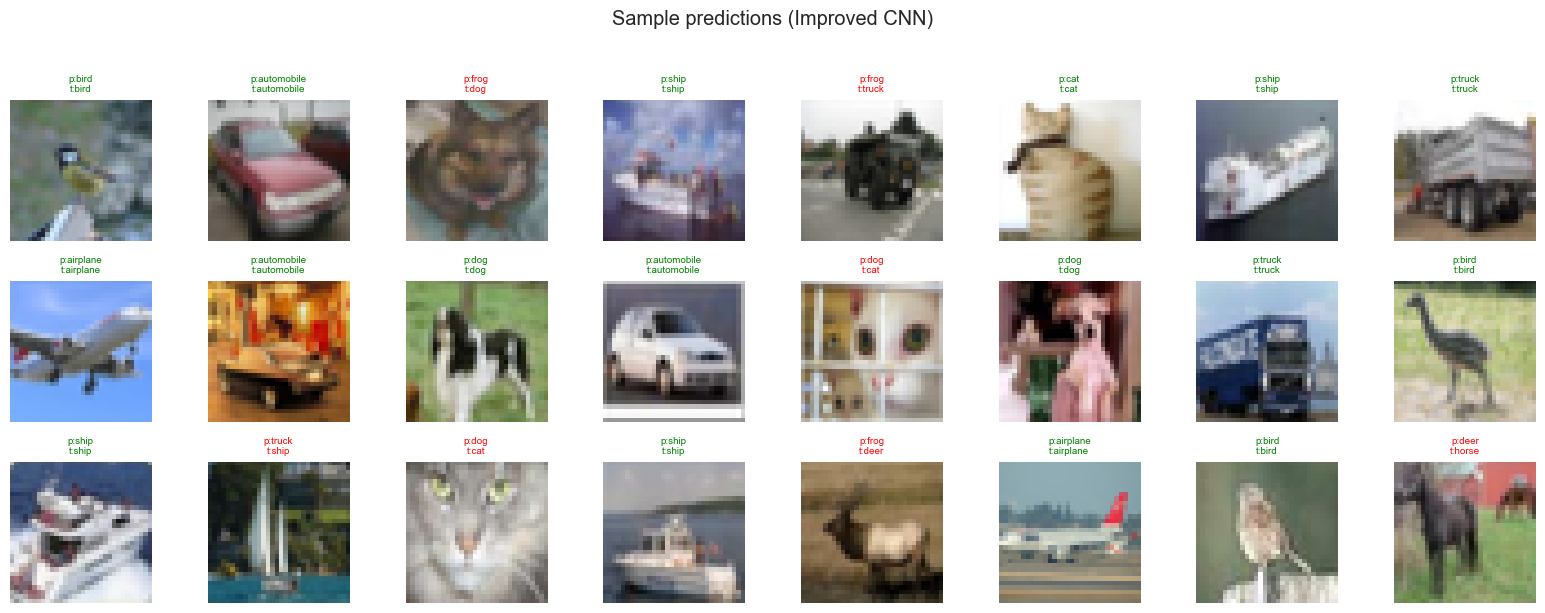

In [19]:
idx = np.random.choice(len(x_test), 24, replace=False)
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for ax, i in zip(axes.flat, idx):
    ax.imshow(x_test[i])
    pred, true = y_pred[i], y_test[i]
    color = 'green' if pred == true else 'red'
    ax.set_title('p:' + class_names[pred] + '\nt:' + class_names[true], fontsize=7, color=color)
    ax.axis('off')
plt.suptitle('Sample predictions (' + best_name + ')', y=1.02)
plt.tight_layout(); plt.show()

## Conclusion

What I did and what I found:

1. Loaded CIFAR-10 (50,000 training and 10,000 test images, 10 balanced classes) and scaled the
   pixels to the 0-1 range.
2. Trained three models: a plain ANN, a basic CNN, and an improved CNN with batch
   normalization, dropout and data augmentation.
3. The ANN was the weakest, as expected, because flattening the image throws away its 2D
   structure. Even a basic CNN beat it clearly by learning local patterns like edges and
   textures.
4. The improved CNN did the best. Batch normalization made training smoother, and dropout plus
   data augmentation kept the gap between training and validation accuracy small, which means
   less overfitting.
5. The confusion matrix shows the usual CIFAR-10 mistakes: cats and dogs get mixed up, and so do
   some vehicles, because they look similar at 32x32 resolution.

### Model selection conclusion

For image data the CNNs clearly beat the fully connected ANN, which is the main lesson here:
using an architecture that matches the data (convolutions for images) matters more than just
adding more dense neurons. Among the CNNs, the improved one with batch norm, dropout and
augmentation generalized best, so that is the model I would pick. If training time were tight I
would use the basic CNN, which is much faster and still far ahead of the ANN.

### Training strategies that helped

- Convolution over fully connected layers: the single biggest jump in accuracy.
- Batch normalization: faster, more stable training.
- Dropout and data augmentation: smaller train/validation gap, so less overfitting.
- Adam optimizer and scaled inputs: reliable training without much tuning.

### Future enhancements

- Train for more epochs on a GPU, which would raise accuracy further (the augmented model was
  still improving).
- Add a learning rate schedule or early stopping.
- Try a well known architecture such as ResNet, or use transfer learning from a model
  pretrained on ImageNet, which usually pushes CIFAR-10 well above 90 percent.